In [1]:
import pandas as pd
import numpy as np
import re
import json
import math
from pathlib import Path

def cargar_json(ruta_archivo):
	with open(ruta_archivo, "r", encoding="utf-8") as archivo:
		return json.load(archivo)

COLUMNAS_DIAS = [
	("L", "lunes_i", "lunes_f"),
	("M", "martes_i", "martes_f"),
	("Mi", "miercoles_i", "miercoles_f"),
	("J", "jueves_i", "jueves_f"),
	("V", "viernes_i", "viernes_f"),
]

COLUMNAS_OBLIGATORIAS_DF_HIST = [
	"tri",
	"tri_num",
	"uea",
	"grupo",
	"eco",
	"lunes_i",
	"lunes_f",
	"martes_i",
	"martes_f",
	"miercoles_i",
	"miercoles_f",
	"jueves_i",
	"jueves_f",
	"viernes_i",
	"viernes_f",
]

def _extraer_hora_minuto_desde_texto(texto):
	texto_normalizado = str(texto).strip()
	if not texto_normalizado:
		return None
	texto_minusculas = texto_normalizado.lower()
	if texto_minusculas in {"nan", "nat", "none", "null"}:
		return None
	if " " in texto_normalizado:
		texto_normalizado = texto_normalizado.split()[-1]
	if "T" in texto_normalizado and ":" in texto_normalizado:
		texto_normalizado = texto_normalizado.split("T")[-1]
	texto_normalizado = texto_normalizado.replace(".", ":")
	coincidencia_hh_mm = re.search(r"(\d{1,2}):(\d{1,2})", texto_normalizado)
	if coincidencia_hh_mm:
		horas = int(coincidencia_hh_mm.group(1))
		minutos = int(coincidencia_hh_mm.group(2))
		if 0 <= horas <= 23 and 0 <= minutos <= 59:
			return horas, minutos
	digitos = re.sub(r"\D", "", texto_normalizado)
	if not digitos:
		return None
	if len(digitos) <= 2:
		horas = int(digitos)
		minutos = 0
	elif len(digitos) == 3:
		horas = int(digitos[0])
		minutos = int(digitos[1:])
	elif len(digitos) == 4:
		horas = int(digitos[:2])
		minutos = int(digitos[2:])
	else:
		return None
	if 0 <= horas <= 23 and 0 <= minutos <= 59:
		return horas, minutos
	return None

def normalizar_texto_hora(valor):
	if valor is None:
		return None
	if pd.isna(valor):
		return None
	partes = _extraer_hora_minuto_desde_texto(valor)
	if partes is None:
		return None
	horas, minutos = partes
	return f"{horas:02d}:{minutos:02d}"

def hora_a_minutos(texto_hora):
	partes = _extraer_hora_minuto_desde_texto(texto_hora)
	if partes is None:
		raise ValueError(f"Hora inválida: {texto_hora!r}")
	horas, minutos = partes
	return horas * 60 + minutos

def minutos_traslape(inicio_a, fin_a, inicio_b, fin_b):
	inicio = max(hora_a_minutos(inicio_a), hora_a_minutos(inicio_b))
	fin = min(hora_a_minutos(fin_a), hora_a_minutos(fin_b))
	return max(0, fin - inicio)

def parsear_bloque_fijo_regular(cadena_bloque):
	partes = str(cadena_bloque).split("-", 1)
	if len(partes) != 2:
		raise ValueError(f"Bloque fijo regular inválido: {cadena_bloque!r}")
	inicio = normalizar_texto_hora(partes[0].strip())
	fin = normalizar_texto_hora(partes[1].strip())
	if not inicio or not fin:
		raise ValueError(f"Bloque fijo regular inválido: {cadena_bloque!r}")
	return {
		dia: [{"inicio": inicio, "fin": fin}]
		for dia, _, _ in COLUMNAS_DIAS
	}

def construir_admin_windows_vacios():
	return {
		dia: []
		for dia, _, _ in COLUMNAS_DIAS
	}

def normalizar_admin_windows(admin_windows):
	admin_windows_normalizados = construir_admin_windows_vacios()
	if admin_windows is None:
		return admin_windows_normalizados
	for dia, ventanas in admin_windows.items():
		if dia not in admin_windows_normalizados:
			continue
		for ventana in ventanas:
			inicio = normalizar_texto_hora(ventana.get("inicio"))
			fin = normalizar_texto_hora(ventana.get("fin"))
			if inicio and fin:
				admin_windows_normalizados[dia].append({
					"inicio": inicio,
					"fin": fin,
				})
	return admin_windows_normalizados

def horario_desde_row(row):
	sesiones = []
	for dia, columna_inicio, columna_fin in COLUMNAS_DIAS:
		inicio = normalizar_texto_hora(row[columna_inicio])
		fin = normalizar_texto_hora(row[columna_fin])
		if inicio and fin:
			sesiones.append({
				"dia": dia,
				"inicio": inicio,
				"fin": fin,
			})
	return {"sesiones": sesiones}

def normalizar_horario_id_desde_df_hist(row):
	partes = []
	for dia, columna_inicio, columna_fin in COLUMNAS_DIAS:
		inicio = normalizar_texto_hora(row[columna_inicio])
		fin = normalizar_texto_hora(row[columna_fin])
		if inicio and fin:
			partes.append(f"{dia}:{inicio}-{fin}")
	return "|".join(partes)

def horario_desde_horario_id(horario_id):
	sesiones = []
	horario_id_normalizado = str(horario_id).strip()
	if not horario_id_normalizado:
		return {"sesiones": sesiones}
	for bloque in horario_id_normalizado.split("|"):
		bloque = bloque.strip()
		if not bloque:
			continue
		if ":" not in bloque:
			raise ValueError(f"Bloque de horario inválido: {bloque!r}")
		dia, rango = bloque.split(":", 1)
		if "-" not in rango:
			raise ValueError(f"Rango de horario inválido: {rango!r}")
		inicio_texto, fin_texto = rango.split("-", 1)
		inicio = normalizar_texto_hora(inicio_texto)
		fin = normalizar_texto_hora(fin_texto)
		if not inicio or not fin:
			raise ValueError(f"Horario inválido en bloque: {bloque!r}")
		sesiones.append({
			"dia": dia,
			"inicio": inicio,
			"fin": fin,
		})
	return {"sesiones": sesiones}

def horario_id_desde_horario(horario):
	partes = []
	for sesion in horario["sesiones"]:
		dia = sesion["dia"]
		inicio = normalizar_texto_hora(sesion["inicio"])
		fin = normalizar_texto_hora(sesion["fin"])
		if inicio and fin:
			partes.append(f"{dia}:{inicio}-{fin}")
	return "|".join(partes)

def construir_fixed_window_regulares(ecos_regulares):
	return {
		str(eco): parsear_bloque_fijo_regular(bloque_fijo)
		for eco, bloque_fijo in ecos_regulares.items()
	}

def normalizar_mascara_ecos(ecos):
	if ecos is None:
		return {}
	return {
		str(eco): valor
		for eco, valor in ecos.items()
	}

def minutos_totales_horario(horario):
	total_minutos = 0
	for sesion in horario["sesiones"]:
		total_minutos += hora_a_minutos(sesion["fin"]) - hora_a_minutos(sesion["inicio"])
	return max(0, total_minutos)

def conjunto_dias_horario(horario):
	return {sesion["dia"] for sesion in horario["sesiones"]}

def similitud_patron_dias(horario_a, horario_b):
	dias_a = conjunto_dias_horario(horario_a)
	dias_b = conjunto_dias_horario(horario_b)
	if not dias_a and not dias_b:
		return 0.0
	union = dias_a | dias_b
	if not union:
		return 0.0
	return len(dias_a & dias_b) / len(union)

def similitud_horaria_por_traslape(horario_a, horario_b):
	total_a = minutos_totales_horario(horario_a)
	total_b = minutos_totales_horario(horario_b)
	if total_a <= 0 or total_b <= 0:
		return 0.0
	traslape_total = 0
	for sesion_a in horario_a["sesiones"]:
		for sesion_b in horario_b["sesiones"]:
			if sesion_a["dia"] != sesion_b["dia"]:
				continue
			traslape_total += minutos_traslape(
				sesion_a["inicio"],
				sesion_a["fin"],
				sesion_b["inicio"],
				sesion_b["fin"],
			)
	return min(1.0, (2.0 * traslape_total) / (total_a + total_b))

def similitud_duracion_horaria(horario_a, horario_b):
	total_a = minutos_totales_horario(horario_a)
	total_b = minutos_totales_horario(horario_b)
	if total_a <= 0 or total_b <= 0:
		return 0.0
	return min(total_a, total_b) / max(total_a, total_b)

def vector_circular_tiempo_horario(horario):
	total_peso = 0.0
	suma_cos = 0.0
	suma_sin = 0.0
	for sesion in horario["sesiones"]:
		inicio = hora_a_minutos(sesion["inicio"])
		fin = hora_a_minutos(sesion["fin"])
		duracion = max(0, fin - inicio)
		if duracion <= 0:
			continue
		punto_medio = (inicio + fin) / 2.0
		angulo = (2.0 * math.pi * punto_medio) / 1440.0
		suma_cos += duracion * math.cos(angulo)
		suma_sin += duracion * math.sin(angulo)
		total_peso += duracion
	if total_peso <= 0.0:
		return np.array([0.0, 0.0], dtype=float)
	vector = np.array([suma_cos / total_peso, suma_sin / total_peso], dtype=float)
	norma = float(np.linalg.norm(vector))
	if norma <= 1e-12:
		return np.array([0.0, 0.0], dtype=float)
	return vector / norma

def similitud_tiempo_circular(horario_a, horario_b):
	vector_a = vector_circular_tiempo_horario(horario_a)
	vector_b = vector_circular_tiempo_horario(horario_b)
	norma_a = float(np.linalg.norm(vector_a))
	norma_b = float(np.linalg.norm(vector_b))
	if norma_a <= 1e-12 or norma_b <= 1e-12:
		return 0.0
	coseno = float(np.dot(vector_a, vector_b))
	coseno = max(-1.0, min(1.0, coseno))
	return (coseno + 1.0) / 2.0

class ModeloPrediccionIHRegular:
	def __init__(
		self,
		lambda_in=1.0,
		lambda_out=1.0,
		lambda_admin_pos=1.0,
		gamma_contrato=0.5,
		gamma_admin=0.15,
		alpha_out=1.0,
		half_life_trimestres=8.0,
		rho_exact=0.35,
		w_overlap=0.40,
		w_duration=0.15,
		w_days=0.20,
		w_time=0.25,
	):
		self.lambda_in = float(lambda_in)
		self.lambda_out = float(lambda_out)
		self.lambda_admin_pos = float(lambda_admin_pos)
		self.gamma_contrato = float(gamma_contrato)
		self.gamma_admin = float(gamma_admin)
		self.alpha_out = float(alpha_out)
		self.half_life_trimestres = float(half_life_trimestres)

		self.rho_exact = float(rho_exact)
		self.w_overlap = float(w_overlap)
		self.w_duration = float(w_duration)
		self.w_days = float(w_days)
		self.w_time = float(w_time)

		self.df_hist = None
		self.tri_num_actual = None
		self.admin_windows = None

		self.ecos_regulares = {}
		self.ecos_irregulares = {}
		self.ecos_vigentes_union = set()

		self.fixed_window_regulares = None
		self.prior_global_h = None
		self.count_out_exact = None
		self.total_out = None
		self.registros_fuera_regular = None

		self.cache_horarios_desde_id = {}
		self.cache_afinidad_overlap = {}

	def peso_reciente(self, tri_num_r):
		delta = self.tri_num_actual - float(tri_num_r)
		return 2.0 ** (-delta / self.half_life_trimestres)

	def obtener_horario_desde_id_cache(self, horario_id):
		horario_id_texto = str(horario_id)
		if horario_id_texto not in self.cache_horarios_desde_id:
			self.cache_horarios_desde_id[horario_id_texto] = horario_desde_horario_id(horario_id_texto)
		return self.cache_horarios_desde_id[horario_id_texto]

	def pesos_kernel_normalizados(self):
		pesos = np.array(
			[
				max(0.0, self.w_overlap),
				max(0.0, self.w_duration),
				max(0.0, self.w_days),
				max(0.0, self.w_time),
			],
			dtype=float,
		)
		suma = float(pesos.sum())
		if suma <= 1e-12:
			return np.array([0.25, 0.25, 0.25, 0.25], dtype=float)
		return pesos / suma

	def firma_kernel(self):
		pesos = self.pesos_kernel_normalizados()
		return tuple(float(round(valor, 12)) for valor in pesos)

	def similitud_horaria_kernelizada(self, horario_objetivo, horario_historico):
		pesos = self.pesos_kernel_normalizados()
		similitud_overlap = similitud_horaria_por_traslape(horario_objetivo, horario_historico)
		similitud_duration = similitud_duracion_horaria(horario_objetivo, horario_historico)
		similitud_days = similitud_patron_dias(horario_objetivo, horario_historico)
		similitud_time = similitud_tiempo_circular(horario_objetivo, horario_historico)
		componentes = np.array(
			[
				similitud_overlap,
				similitud_duration,
				similitud_days,
				similitud_time,
			],
			dtype=float,
		)
		return float(np.dot(pesos, componentes))

	def construir_prior_global_horario(self, df_hist):
		count_global_h = {}
		total_global = 0.0
		for _, row in df_hist.iterrows():
			horario_id = row["horario_id"]
			if not horario_id:
				continue
			peso = float(row["peso_reciente"])
			count_global_h[horario_id] = count_global_h.get(horario_id, 0.0) + peso
			total_global += peso
		if total_global == 0.0:
			return {}
		return {
			horario_id: conteo / total_global
			for horario_id, conteo in count_global_h.items()
		}

	def cobertura_contrato_regular(self, eco, horario):
		eco_texto = str(eco)
		if eco_texto not in self.fixed_window_regulares:
			return 0.0
		fixed_window = self.fixed_window_regulares[eco_texto]
		total_minutos_horario = 0
		total_minutos_dentro = 0
		for sesion in horario["sesiones"]:
			dia = sesion["dia"]
			inicio_clase = sesion["inicio"]
			fin_clase = sesion["fin"]
			total_minutos_horario += hora_a_minutos(fin_clase) - hora_a_minutos(inicio_clase)
			for ventana in fixed_window.get(dia, []):
				total_minutos_dentro += minutos_traslape(
					inicio_clase,
					fin_clase,
					ventana["inicio"],
					ventana["fin"],
				)
		if total_minutos_horario <= 0:
			return 0.0
		return total_minutos_dentro / total_minutos_horario

	def construir_componentes_fuera_regular(self, df_hist):
		count_out_exact = {
			eco: {}
			for eco in self.fixed_window_regulares.keys()
		}
		total_out = {
			eco: 0.0
			for eco in self.fixed_window_regulares.keys()
		}
		registros_fuera_regular = {
			eco: []
			for eco in self.fixed_window_regulares.keys()
		}
		for _, row in df_hist.iterrows():
			eco = str(row["eco"])
			if eco not in self.fixed_window_regulares:
				continue
			horario_id = row["horario_id"]
			if not horario_id:
				continue
			horario = row["horario"]
			afinidad_contrato = self.cobertura_contrato_regular(eco, horario)
			if afinidad_contrato >= 1.0:
				continue
			peso = float(row["peso_reciente"])
			count_out_exact[eco][horario_id] = count_out_exact[eco].get(horario_id, 0.0) + peso
			total_out[eco] += peso
			registros_fuera_regular[eco].append(
				{
					"horario_id": horario_id,
					"horario": horario,
					"peso": peso,
				}
			)
		return count_out_exact, total_out, registros_fuera_regular

	def afinidad_fuera_exacta_regular(self, eco, horario_id):
		eco_texto = str(eco)
		return (
			self.count_out_exact.get(eco_texto, {}).get(horario_id, 0.0)
			+ self.alpha_out * self.prior_global_h.get(horario_id, 0.0)
		) / (
			self.total_out.get(eco_texto, 0.0) + self.alpha_out
		)

	def afinidad_fuera_overlap_regular(self, eco, horario_id):
		eco_texto = str(eco)
		firma_kernel = self.firma_kernel()
		cache_key = (eco_texto, str(horario_id), firma_kernel)
		if cache_key in self.cache_afinidad_overlap:
			return self.cache_afinidad_overlap[cache_key]

		horario_objetivo = self.obtener_horario_desde_id_cache(horario_id)
		registros = self.registros_fuera_regular.get(eco_texto, [])
		total_peso = self.total_out.get(eco_texto, 0.0)

		if total_peso <= 0.0 or not registros:
			self.cache_afinidad_overlap[cache_key] = 0.0
			return 0.0

		masa_overlap = 0.0
		for registro in registros:
			similitud = self.similitud_horaria_kernelizada(horario_objetivo, registro["horario"])
			masa_overlap += float(registro["peso"]) * similitud

		afinidad_overlap = masa_overlap / total_peso
		self.cache_afinidad_overlap[cache_key] = afinidad_overlap
		return afinidad_overlap

	def componentes_afinidad_fuera_regular(self, eco, horario_id):
		afinidad_exacta = self.afinidad_fuera_exacta_regular(eco, horario_id)
		afinidad_overlap = self.afinidad_fuera_overlap_regular(eco, horario_id)
		rho_exact_clamp = max(0.0, min(1.0, self.rho_exact))
		afinidad_total = rho_exact_clamp * afinidad_exacta + (1.0 - rho_exact_clamp) * afinidad_overlap
		return {
			"afinidad_fuera_historica_exacta": afinidad_exacta,
			"afinidad_fuera_historica_overlap": afinidad_overlap,
			"afinidad_fuera_historica": afinidad_total,
		}

	def afinidad_fuera_historica_regular(self, eco, horario_id):
		return self.componentes_afinidad_fuera_regular(eco, horario_id)["afinidad_fuera_historica"]

	def preferencia_admin(self, horario):
		total_minutos_horario = 0
		total_minutos_preferidos = 0
		for sesion in horario["sesiones"]:
			dia = sesion["dia"]
			inicio_clase = sesion["inicio"]
			fin_clase = sesion["fin"]
			total_minutos_horario += hora_a_minutos(fin_clase) - hora_a_minutos(inicio_clase)
			for ventana in self.admin_windows.get(dia, []):
				total_minutos_preferidos += minutos_traslape(
					inicio_clase,
					fin_clase,
					ventana["inicio"],
					ventana["fin"],
				)
		if total_minutos_horario <= 0:
			return 0.0
		return total_minutos_preferidos / total_minutos_horario

	def score_horario_regular(self, eco, horario_id, horario):
		afinidad_contrato = self.cobertura_contrato_regular(eco, horario)
		componentes_afinidad = self.componentes_afinidad_fuera_regular(eco, horario_id)
		afinidad_fuera_historica = componentes_afinidad["afinidad_fuera_historica"]
		preferencia_administrativa = self.preferencia_admin(horario)

		bonus_contrato = self.lambda_in * afinidad_contrato
		bonus_fuera_justificado = self.lambda_out * (1.0 - afinidad_contrato) * afinidad_fuera_historica
		bonus_admin = self.lambda_admin_pos * preferencia_administrativa

		penalizacion_fuera_no_justificada = (
			self.gamma_contrato
			* (1.0 - afinidad_contrato)
			* (1.0 - afinidad_fuera_historica)
		)

		penalizacion_admin = self.gamma_admin * (1.0 - preferencia_administrativa)

		score_lineal = (
			bonus_contrato
			+ bonus_fuera_justificado
			+ bonus_admin
			- penalizacion_fuera_no_justificada
			- penalizacion_admin
		)

		score_horario_regular = min(1.0, max(0.0, score_lineal))

		return {
			"eco": str(eco),
			"horario_id": horario_id,
			"afinidad_contrato": afinidad_contrato,
			"afinidad_fuera_historica_exacta": componentes_afinidad["afinidad_fuera_historica_exacta"],
			"afinidad_fuera_historica_overlap": componentes_afinidad["afinidad_fuera_historica_overlap"],
			"afinidad_fuera_historica": afinidad_fuera_historica,
			"rho_exact": max(0.0, min(1.0, self.rho_exact)),
			"prior_global_h": self.prior_global_h.get(horario_id, 0.0),
			"preferencia_administrativa": preferencia_administrativa,
			"bonus_contrato": bonus_contrato,
			"bonus_fuera_justificado": bonus_fuera_justificado,
			"bonus_admin": bonus_admin,
			"penalizacion_fuera_no_justificada": penalizacion_fuera_no_justificada,
			"penalizacion_admin": penalizacion_admin,
			"score_lineal": score_lineal,
			"score_horario_regular": score_horario_regular,
			"kernel_weights": {
				"w_overlap": float(self.pesos_kernel_normalizados()[0]),
				"w_duration": float(self.pesos_kernel_normalizados()[1]),
				"w_days": float(self.pesos_kernel_normalizados()[2]),
				"w_time": float(self.pesos_kernel_normalizados()[3]),
			},
		}

	def fit(
		self,
		df_hist,
		ecos_regulares,
		ecos_irregulares=None,
		admin_windows=None,
		tri_num_actual=None,
	):
		columnas_faltantes = [
			columna
			for columna in COLUMNAS_OBLIGATORIAS_DF_HIST
			if columna not in df_hist.columns
		]
		if columnas_faltantes:
			raise ValueError(f"Faltan columnas obligatorias en df_hist: {columnas_faltantes}")

		df_hist_entrenamiento = df_hist.copy()
		df_hist_entrenamiento["eco"] = df_hist_entrenamiento["eco"].astype(str)
		df_hist_entrenamiento["tri_num"] = pd.to_numeric(df_hist_entrenamiento["tri_num"], errors="raise")

		for _, columna_inicio, columna_fin in COLUMNAS_DIAS:
			df_hist_entrenamiento[columna_inicio] = df_hist_entrenamiento[columna_inicio].apply(normalizar_texto_hora)
			df_hist_entrenamiento[columna_fin] = df_hist_entrenamiento[columna_fin].apply(normalizar_texto_hora)

		df_hist_entrenamiento["horario"] = df_hist_entrenamiento.apply(horario_desde_row, axis=1)
		df_hist_entrenamiento["horario_id"] = df_hist_entrenamiento.apply(normalizar_horario_id_desde_df_hist, axis=1)

		self.df_hist = df_hist_entrenamiento
		self.tri_num_actual = float(
			df_hist_entrenamiento["tri_num"].max()
			if tri_num_actual is None
			else tri_num_actual
		)

		self.df_hist["peso_reciente"] = self.df_hist["tri_num"].apply(self.peso_reciente)

		self.ecos_regulares = normalizar_mascara_ecos(ecos_regulares)
		self.ecos_irregulares = normalizar_mascara_ecos(ecos_irregulares)
		self.ecos_vigentes_union = set(self.ecos_regulares.keys()) | set(self.ecos_irregulares.keys())

		self.fixed_window_regulares = construir_fixed_window_regulares(self.ecos_regulares)
		self.admin_windows = normalizar_admin_windows(admin_windows)

		self.cache_horarios_desde_id = {}
		self.cache_afinidad_overlap = {}

		self.prior_global_h = self.construir_prior_global_horario(self.df_hist)
		self.count_out_exact, self.total_out, self.registros_fuera_regular = self.construir_componentes_fuera_regular(self.df_hist)

		return self

	def predecir(self, eco, horario_id=None, horario=None):
		eco_texto = str(eco)

		if eco_texto not in self.fixed_window_regulares:
			raise ValueError(f"El eco {eco_texto!r} no está en la máscara de regulares")

		if horario is None and horario_id is None:
			raise ValueError("Debes proporcionar horario o horario_id")

		if isinstance(horario, str):
			horario_id = horario
			horario = None

		if horario is None:
			horario = self.obtener_horario_desde_id_cache(horario_id)

		if horario_id is None:
			horario_id = horario_id_desde_horario(horario)

		return self.score_horario_regular(
			eco=eco_texto,
			horario_id=horario_id,
			horario=horario,
		)

In [4]:
rutas_archivos = {
	"historico": Path("df_hist.json"),
	"regulares": Path("ecos_vigentes_con_horario_regular.json"),
	"irregulares": Path("ecos_vigentes_con_horario_irregular.json"),
	"nombres": Path("eco-nombre.json"),
}

df_hist = pd.DataFrame(cargar_json(rutas_archivos["historico"]))
ecos_regulares = cargar_json(rutas_archivos["regulares"])
ecos_irregulares = cargar_json(rutas_archivos["irregulares"])
eco_nombres = cargar_json(rutas_archivos["nombres"]) if rutas_archivos["nombres"].exists() else {}




In [5]:
admin_windows = {
	"L": [
		{"inicio": "10:00", "fin": "14:00"},
		{"inicio": "16:00", "fin": "18:00"},
	],
	"M": [
		{"inicio": "10:00", "fin": "14:00"},
		{"inicio": "16:00", "fin": "18:00"},
	],
	"Mi": [
		{"inicio": "10:00", "fin": "14:00"},
		{"inicio": "16:00", "fin": "18:00"},
	],
	"J": [
		{"inicio": "10:00", "fin": "14:00"},
		{"inicio": "16:00", "fin": "18:00"},
	],
	"V": [
		{"inicio": "10:00", "fin": "14:00"},
		{"inicio": "16:00", "fin": "18:00"},
	],
}

hiperparametros = {
	"lambda_in": 1.0,
	"lambda_out": 0.9,
	"lambda_admin_pos": 1.0,
	"gamma_contrato": 0.9,
	"gamma_admin": 0.15,
	"alpha_out": 1.0,
	"half_life_trimestres": 8.0,
}

modelo_ih_regular = ModeloPrediccionIHRegular(**hiperparametros).fit(
	df_hist=df_hist,
	ecos_regulares=ecos_regulares,
	ecos_irregulares=ecos_irregulares,
	admin_windows=admin_windows,
)

fixed_window_regulares = modelo_ih_regular.fixed_window_regulares
prior_global_h = modelo_ih_regular.prior_global_h
count_out_exact = modelo_ih_regular.count_out_exact
total_out = modelo_ih_regular.total_out

resumen_entrenamiento = {
	"tri_num_actual": modelo_ih_regular.tri_num_actual,
	"ecos_regulares": len(modelo_ih_regular.ecos_regulares),
	"ecos_irregulares_cargados": len(modelo_ih_regular.ecos_irregulares),
	"horarios_globales_observados": len(prior_global_h),
	"ecos_con_historia_fuera_de_bloque": sum(
		1 for total_eco in total_out.values() if total_eco > 0
	),
}

resumen_entrenamiento

{'tri_num_actual': 31.0,
 'ecos_regulares': 82,
 'ecos_irregulares_cargados': 36,
 'horarios_globales_observados': 1228,
 'ecos_con_historia_fuera_de_bloque': 82}

In [6]:
eco_prediccion = "4377"
horario = "14:30-16:00"
horario_id_prediccion = "L:"+horario+"|Mi:"+horario+"|V:"+horario

prediccion = modelo_ih_regular.predecir(
	eco=eco_prediccion,
	horario_id=horario_id_prediccion,
)

prediccion


{'eco': '4377',
 'horario_id': 'L:14:30-16:00|Mi:14:30-16:00|V:14:30-16:00',
 'afinidad_contrato': 0.3333333333333333,
 'afinidad_fuera_historica_exacta': 0.20878288055360858,
 'afinidad_fuera_historica_overlap': 0.6947623650890306,
 'afinidad_fuera_historica': 0.5246695455016329,
 'rho_exact': 0.35,
 'prior_global_h': 0.027732325583081422,
 'preferencia_administrativa': 0.0,
 'bonus_contrato': 0.3333333333333333,
 'bonus_fuera_justificado': 0.3148017273009798,
 'bonus_admin': 0.0,
 'penalizacion_fuera_no_justificada': 0.2851982726990203,
 'penalizacion_admin': 0.15,
 'score_lineal': 0.21293678793529272,
 'score_horario_regular': 0.21293678793529272,
 'kernel_weights': {'w_overlap': 0.4,
  'w_duration': 0.15,
  'w_days': 0.2,
  'w_time': 0.25}}

Combinaciones evaluadas: 2,916
Parámetros base


,grupo,parametro,valor
0,afinidad,alpha_out,1.00
1,afinidad,rho_exact,0.35
2,afinidad,w_days,0.20
3,afinidad,w_duration,0.15
4,afinidad,w_overlap,0.40
5,afinidad,w_time,0.25
6,score,gamma_admin,0.15
7,score,gamma_contrato,0.90
8,score,lambda_admin_pos,1.00
9,score,lambda_in,1.00


Loss baseline datos: 0.4234757682
Loss baseline total: 0.4234757682
Abs baseline: 1.1432981525
Resultados baseline


,eco,horario_id,target,peso,pred,error,abs_error,weighted_sq_error,afinidad_contrato,afinidad_fuera_historica_exacta,...,bonus_contrato,bonus_fuera_justificado,bonus_admin,penalizacion_fuera_no_justificada,penalizacion_admin,score_lineal,w_overlap_norm,w_duration_norm,w_days_norm,w_time_norm
0,4377,L:14:30-16:00|Mi:14:30-16:00|V:14:30-16:00,0.75,1.0,0.212937,-0.537063,0.537063,0.288437,0.333333,0.208783,...,0.333333,0.314802,0.000000,0.285198,0.15,0.212937,0.4,0.15,0.2,0.25
1,4377,L:16:00-17:30|Mi:16:00-17:30|V:16:00-17:30,0.75,1.0,1.000000,0.250000,0.250000,0.062500,0.000000,0.386219,...,0.000000,0.536696,1.000000,0.363304,0.00,1.173391,0.4,0.15,0.2,0.25
2,4377,L:13:00-14:30|Mi:13:00-14:30|V:13:00-14:30,0.75,1.0,1.000000,0.250000,0.250000,0.062500,1.000000,0.000715,...,1.000000,0.000000,0.666667,0.000000,0.05,1.616667,0.4,0.15,0.2,0.25
3,28650,L:16:30-17:30|Mi:16:30-17:30|V:16:30-17:30,0.90,1.0,1.000000,0.100000,0.100000,0.010000,1.000000,0.000000,...,1.000000,0.000000,1.000000,0.000000,0.00,2.000000,0.4,0.15,0.2,0.25
4,28650,L:17:30-19:00|Mi:17:30-19:00|V:17:30-19:00,0.75,1.0,0.756235,0.006235,0.006235,0.000039,0.333333,0.483017,...,0.333333,0.394784,0.333333,0.205216,0.10,0.756235,0.4,0.15,0.2,0.25


Mejores hiperparámetros


,grupo,parametro,valor
0,afinidad,alpha_out,1.000000
1,afinidad,rho_exact,0.082000
2,afinidad,w_days,0.255042
3,afinidad,w_duration,0.255042
4,afinidad,w_overlap,0.156584
5,afinidad,w_time,0.333333
6,score,gamma_admin,0.000000
7,score,gamma_contrato,0.575000
8,score,lambda_admin_pos,0.336000
9,score,lambda_in,1.152000


Loss óptimo datos: 0.0829730334
Regularización óptima: 0.0506388889
Loss óptimo total: 0.1336119223
Abs óptimo: 0.4791705454
Resultados óptimos


,eco,horario_id,target,peso,pred,error,abs_error,weighted_sq_error,afinidad_contrato,afinidad_fuera_historica_exacta,...,bonus_contrato,bonus_fuera_justificado,bonus_admin,penalizacion_fuera_no_justificada,penalizacion_admin,score_lineal,w_overlap_norm,w_duration_norm,w_days_norm,w_time_norm
0,4377,L:14:30-16:00|Mi:14:30-16:00|V:14:30-16:00,0.75,1.0,0.649999,-0.100001,0.100001,0.010000,0.333333,0.208783,...,0.384,0.356496,0.000,0.090497,0.0,0.649999,0.156584,0.255042,0.255042,0.333333
1,4377,L:16:00-17:30|Mi:16:00-17:30|V:16:00-17:30,0.75,1.0,0.759713,0.009713,0.009713,0.000094,0.000000,0.386219,...,0.000,0.548313,0.336,0.124600,0.0,0.759713,0.156584,0.255042,0.255042,0.333333
2,4377,L:13:00-14:30|Mi:13:00-14:30|V:13:00-14:30,0.75,1.0,1.000000,0.250000,0.250000,0.062500,1.000000,0.000715,...,1.152,0.000000,0.224,0.000000,0.0,1.376000,0.156584,0.255042,0.255042,0.333333
3,28650,L:16:30-17:30|Mi:16:30-17:30|V:16:30-17:30,0.90,1.0,1.000000,0.100000,0.100000,0.010000,1.000000,0.000000,...,1.152,0.000000,0.336,0.000000,0.0,1.488000,0.156584,0.255042,0.255042,0.333333
4,28650,L:17:30-19:00|Mi:17:30-19:00|V:17:30-19:00,0.75,1.0,0.769457,0.019457,0.019457,0.000379,0.333333,0.483017,...,0.384,0.360591,0.112,0.087134,0.0,0.769457,0.156584,0.255042,0.255042,0.333333


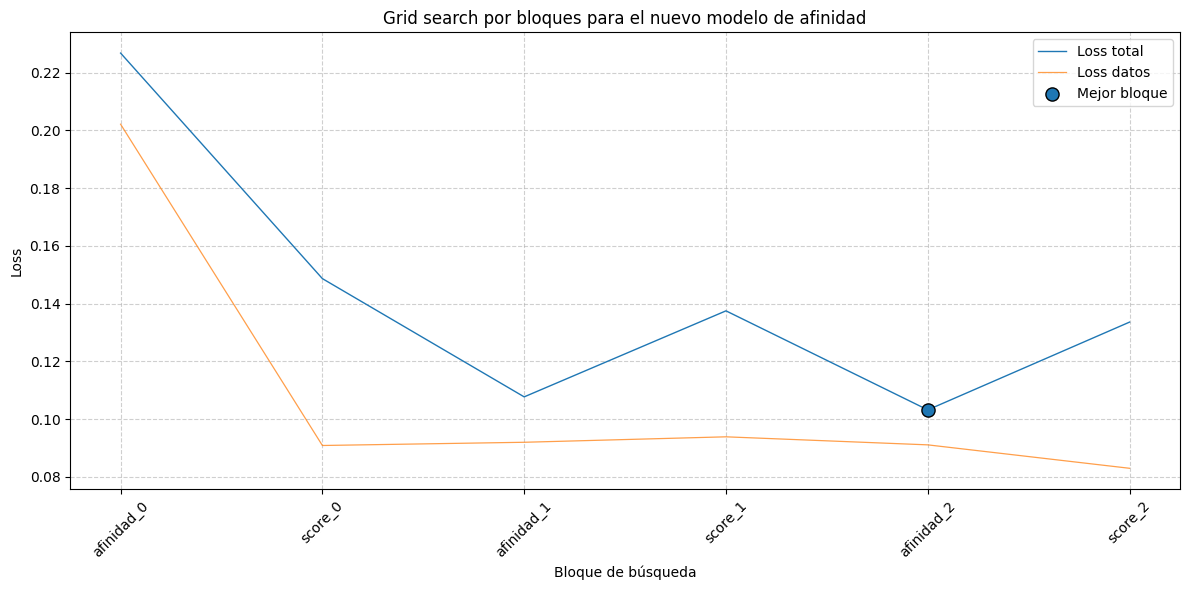

In [7]:
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "modelo_ih_regular" not in globals():
	raise ValueError("No existe modelo_ih_regular en memoria. Entrena o carga el modelo antes de correr esta celda.")

objetivos_ih = [
	{
		"eco": "4377",
		"horario_id": "L:14:30-16:00|Mi:14:30-16:00|V:14:30-16:00",
		"target": 0.75,
		"peso": 1.0,
	},
	{
		"eco": "4377",
		"horario_id": "L:16:00-17:30|Mi:16:00-17:30|V:16:00-17:30",
		"target": 0.75,
		"peso": 1.0,
	},
	{
		"eco": "4377",
		"horario_id": "L:13:00-14:30|Mi:13:00-14:30|V:13:00-14:30",
		"target": 0.75,
		"peso": 1.0,
	},
	{
		"eco": "28650",
		"horario_id": "L:16:30-17:30|Mi:16:30-17:30|V:16:30-17:30",
		"target": 0.90,
		"peso": 1.0,
	},
	{
		"eco": "28650",
		"horario_id": "L:17:30-19:00|Mi:17:30-19:00|V:17:30-19:00",
		"target": 0.75,
		"peso": 1.0,
	},
]

parametros_base_afinidad_ih = {
	"alpha_out": float(modelo_ih_regular.alpha_out),
	"rho_exact": float(modelo_ih_regular.rho_exact),
	"w_overlap": float(modelo_ih_regular.w_overlap),
	"w_duration": float(modelo_ih_regular.w_duration),
	"w_days": float(modelo_ih_regular.w_days),
	"w_time": float(modelo_ih_regular.w_time),
}

parametros_base_score_ih = {
	"lambda_in": float(modelo_ih_regular.lambda_in),
	"lambda_out": float(modelo_ih_regular.lambda_out),
	"lambda_admin_pos": float(modelo_ih_regular.lambda_admin_pos),
	"gamma_contrato": float(modelo_ih_regular.gamma_contrato),
	"gamma_admin": float(modelo_ih_regular.gamma_admin),
}

rangos_afinidad_ih = {
	"alpha_out": (0.25, 4.0),
	"rho_exact": (0.05, 0.85),
	"w_overlap": (0.10, 0.90),
	"w_duration": (0.05, 0.60),
	"w_days": (0.05, 0.60),
	"w_time": (0.05, 0.60),
}

rangos_score_ih = {
	"lambda_in": (0.40, 1.20),
	"lambda_out": (0.50, 2.50),
	"lambda_admin_pos": (0.00, 0.80),
	"gamma_contrato": (0.05, 0.80),
	"gamma_admin": (0.00, 0.50),
}

peso_regularizacion_afinidad_ih = 0.05
peso_regularizacion_score_ih = 0.05

puntos_grid_inicial_afinidad = 3
puntos_grid_refinado_afinidad = 3
puntos_grid_inicial_score = 3
puntos_grid_refinado_score = 3
numero_refinamientos = 2
factor_contraccion = 0.40

def normalizar_pesos_kernel(raw_weights):
	vector = np.array(
		[
			max(0.0, float(raw_weights["w_overlap"])),
			max(0.0, float(raw_weights["w_duration"])),
			max(0.0, float(raw_weights["w_days"])),
			max(0.0, float(raw_weights["w_time"])),
		],
		dtype=float,
	)
	suma = float(vector.sum())
	if suma <= 1e-12:
		vector = np.array([0.25, 0.25, 0.25, 0.25], dtype=float)
	else:
		vector = vector / suma
	return {
		"w_overlap": float(vector[0]),
		"w_duration": float(vector[1]),
		"w_days": float(vector[2]),
		"w_time": float(vector[3]),
	}

def aplicar_parametros_modelo(modelo, params_afinidad, params_score):
	for nombre, valor in params_afinidad.items():
		setattr(modelo, nombre, float(valor))
	for nombre, valor in params_score.items():
		setattr(modelo, nombre, float(valor))

def construir_grid_desde_rangos(rangos, puntos_por_parametro):
	return {
		parametro: np.linspace(limite_inferior, limite_superior, puntos_por_parametro)
		for parametro, (limite_inferior, limite_superior) in rangos.items()
	}

def contraer_rangos(rangos_base, mejor_params, factor):
	rangos_contraidos = {}
	for parametro, (limite_inferior, limite_superior) in rangos_base.items():
		centro = float(mejor_params[parametro])
		span_total = limite_superior - limite_inferior
		nuevo_span = span_total * factor
		nuevo_inferior = max(limite_inferior, centro - nuevo_span / 2.0)
		nuevo_superior = min(limite_superior, centro + nuevo_span / 2.0)
		if math.isclose(nuevo_inferior, nuevo_superior):
			nuevo_inferior = centro
			nuevo_superior = centro
		rangos_contraidos[parametro] = (nuevo_inferior, nuevo_superior)
	return rangos_contraidos

def calcular_regularizacion_normalizada(params, params_base, rangos, peso_regularizacion):
	acumulado = 0.0
	for parametro, valor in params.items():
		limite_inferior, limite_superior = rangos[parametro]
		span = limite_superior - limite_inferior
		if span <= 1e-12:
			continue
		acumulado += ((float(valor) - float(params_base[parametro])) / span) ** 2
	return peso_regularizacion * acumulado

def precomputar_estadisticas_objetivos(modelo, objetivos):
	rows = []

	for objetivo in objetivos:
		eco = str(objetivo["eco"])
		horario_id = str(objetivo["horario_id"])
		horario_objetivo = modelo.obtener_horario_desde_id_cache(horario_id)

		afinidad_contrato = float(modelo.cobertura_contrato_regular(eco, horario_objetivo))
		preferencia_administrativa = float(modelo.preferencia_admin(horario_objetivo))
		prior_global_h = float(modelo.prior_global_h.get(horario_id, 0.0))
		conteo_exacto = float(modelo.count_out_exact.get(eco, {}).get(horario_id, 0.0))
		total_out = float(modelo.total_out.get(eco, 0.0))

		registros = modelo.registros_fuera_regular.get(eco, [])

		masa_overlap = 0.0
		masa_duration = 0.0
		masa_days = 0.0
		masa_time = 0.0

		for registro in registros:
			peso = float(registro["peso"])
			horario_historico = registro["horario"]

			masa_overlap += peso * float(similitud_horaria_por_traslape(horario_objetivo, horario_historico))
			masa_duration += peso * float(similitud_duracion_horaria(horario_objetivo, horario_historico))
			masa_days += peso * float(similitud_patron_dias(horario_objetivo, horario_historico))
			masa_time += peso * float(similitud_tiempo_circular(horario_objetivo, horario_historico))

		if total_out > 0.0:
			componente_overlap = masa_overlap / total_out
			componente_duration = masa_duration / total_out
			componente_days = masa_days / total_out
			componente_time = masa_time / total_out
		else:
			componente_overlap = 0.0
			componente_duration = 0.0
			componente_days = 0.0
			componente_time = 0.0

		rows.append(
			{
				"eco": eco,
				"horario_id": horario_id,
				"target": float(objetivo["target"]),
				"peso": float(objetivo.get("peso", 1.0)),
				"afinidad_contrato": afinidad_contrato,
				"preferencia_administrativa": preferencia_administrativa,
				"prior_global_h": prior_global_h,
				"conteo_exacto_fuera": conteo_exacto,
				"total_out": total_out,
				"componente_overlap": componente_overlap,
				"componente_duration": componente_duration,
				"componente_days": componente_days,
				"componente_time": componente_time,
			}
		)

	return pd.DataFrame(rows)

def evaluar_con_parametros(stats_df, params_afinidad, params_score):
	pesos_kernel = normalizar_pesos_kernel(params_afinidad)

	alpha_out = float(params_afinidad["alpha_out"])
	rho_exact = max(0.0, min(1.0, float(params_afinidad["rho_exact"])))

	conteo_exacto = stats_df["conteo_exacto_fuera"].to_numpy(dtype=float)
	total_out = stats_df["total_out"].to_numpy(dtype=float)
	prior_global_h = stats_df["prior_global_h"].to_numpy(dtype=float)

	afinidad_exacta = (conteo_exacto + alpha_out * prior_global_h) / (total_out + alpha_out)

	afinidad_overlap = (
		pesos_kernel["w_overlap"] * stats_df["componente_overlap"].to_numpy(dtype=float)
		+ pesos_kernel["w_duration"] * stats_df["componente_duration"].to_numpy(dtype=float)
		+ pesos_kernel["w_days"] * stats_df["componente_days"].to_numpy(dtype=float)
		+ pesos_kernel["w_time"] * stats_df["componente_time"].to_numpy(dtype=float)
	)

	afinidad_total = rho_exact * afinidad_exacta + (1.0 - rho_exact) * afinidad_overlap

	afinidad_contrato = stats_df["afinidad_contrato"].to_numpy(dtype=float)
	preferencia_administrativa = stats_df["preferencia_administrativa"].to_numpy(dtype=float)
	target = stats_df["target"].to_numpy(dtype=float)
	peso = stats_df["peso"].to_numpy(dtype=float)

	lambda_in = float(params_score["lambda_in"])
	lambda_out = float(params_score["lambda_out"])
	lambda_admin_pos = float(params_score["lambda_admin_pos"])
	gamma_contrato = float(params_score["gamma_contrato"])
	gamma_admin = float(params_score["gamma_admin"])

	bonus_contrato = lambda_in * afinidad_contrato
	bonus_fuera_justificado = lambda_out * (1.0 - afinidad_contrato) * afinidad_total
	bonus_admin = lambda_admin_pos * preferencia_administrativa

	penalizacion_fuera_no_justificada = gamma_contrato * (1.0 - afinidad_contrato) * (1.0 - afinidad_total)
	penalizacion_admin = gamma_admin * (1.0 - preferencia_administrativa)

	score_lineal = (
		bonus_contrato
		+ bonus_fuera_justificado
		+ bonus_admin
		- penalizacion_fuera_no_justificada
		- penalizacion_admin
	)

	pred = np.clip(score_lineal, 0.0, 1.0)
	error = pred - target
	abs_error = np.abs(error)
	weighted_sq_error = peso * (error ** 2)

	df_eval = stats_df[["eco", "horario_id", "target", "peso"]].copy()
	df_eval["pred"] = pred
	df_eval["error"] = error
	df_eval["abs_error"] = abs_error
	df_eval["weighted_sq_error"] = weighted_sq_error
	df_eval["afinidad_contrato"] = afinidad_contrato
	df_eval["afinidad_fuera_historica_exacta"] = afinidad_exacta
	df_eval["afinidad_fuera_historica_overlap"] = afinidad_overlap
	df_eval["afinidad_fuera_historica"] = afinidad_total
	df_eval["rho_exact"] = rho_exact
	df_eval["prior_global_h"] = prior_global_h
	df_eval["preferencia_administrativa"] = preferencia_administrativa
	df_eval["bonus_contrato"] = bonus_contrato
	df_eval["bonus_fuera_justificado"] = bonus_fuera_justificado
	df_eval["bonus_admin"] = bonus_admin
	df_eval["penalizacion_fuera_no_justificada"] = penalizacion_fuera_no_justificada
	df_eval["penalizacion_admin"] = penalizacion_admin
	df_eval["score_lineal"] = score_lineal
	df_eval["w_overlap_norm"] = pesos_kernel["w_overlap"]
	df_eval["w_duration_norm"] = pesos_kernel["w_duration"]
	df_eval["w_days_norm"] = pesos_kernel["w_days"]
	df_eval["w_time_norm"] = pesos_kernel["w_time"]

	return float(weighted_sq_error.sum()), float(abs_error.sum()), df_eval

def evaluar_grid_afinidad(stats_df, grid_afinidad, params_score_fijos, params_base_afinidad, rangos_afinidad, peso_regularizacion, historial, etiqueta):
	claves_grid = list(grid_afinidad.keys())
	valores_grid = [grid_afinidad[clave] for clave in claves_grid]

	best_loss_total = float("inf")
	best_loss_datos = float("inf")
	best_abs = float("inf")
	best_reg = float("inf")
	best_params = None
	best_df_eval = None
	total_evaluadas = 0

	for combinacion in itertools.product(*valores_grid):
		total_evaluadas += 1
		params_afinidad = {
			clave: float(valor)
			for clave, valor in zip(claves_grid, combinacion)
		}

		loss_datos, abs_loss, df_eval = evaluar_con_parametros(
			stats_df=stats_df,
			params_afinidad=params_afinidad,
			params_score=params_score_fijos,
		)

		reg = calcular_regularizacion_normalizada(
			params=params_afinidad,
			params_base=params_base_afinidad,
			rangos=rangos_afinidad,
			peso_regularizacion=peso_regularizacion,
		)

		loss_total = loss_datos + reg

		if (loss_total < best_loss_total) or (math.isclose(loss_total, best_loss_total) and abs_loss < best_abs):
			best_loss_total = loss_total
			best_loss_datos = loss_datos
			best_abs = abs_loss
			best_reg = reg
			best_params = dict(params_afinidad)
			best_df_eval = df_eval.copy()

	historial.append(
		{
			"bloque": etiqueta,
			"loss_total": best_loss_total,
			"loss_datos": best_loss_datos,
			"regularizacion": best_reg,
			"best_params": dict(best_params),
		}
	)

	return {
		"best_loss_total": best_loss_total,
		"best_loss_datos": best_loss_datos,
		"best_abs": best_abs,
		"best_reg": best_reg,
		"best_params": best_params,
		"best_df_eval": best_df_eval,
		"total_evaluadas": total_evaluadas,
	}

def evaluar_grid_score(stats_df, params_afinidad_fijos, grid_score, params_base_score, rangos_score, peso_regularizacion, historial, etiqueta):
	claves_grid = list(grid_score.keys())
	valores_grid = [grid_score[clave] for clave in claves_grid]

	best_loss_total = float("inf")
	best_loss_datos = float("inf")
	best_abs = float("inf")
	best_reg = float("inf")
	best_params = None
	best_df_eval = None
	total_evaluadas = 0

	for combinacion in itertools.product(*valores_grid):
		total_evaluadas += 1
		params_score = {
			clave: float(valor)
			for clave, valor in zip(claves_grid, combinacion)
		}

		loss_datos, abs_loss, df_eval = evaluar_con_parametros(
			stats_df=stats_df,
			params_afinidad=params_afinidad_fijos,
			params_score=params_score,
		)

		reg = calcular_regularizacion_normalizada(
			params=params_score,
			params_base=params_base_score,
			rangos=rangos_score,
			peso_regularizacion=peso_regularizacion,
		)

		loss_total = loss_datos + reg

		if (loss_total < best_loss_total) or (math.isclose(loss_total, best_loss_total) and abs_loss < best_abs):
			best_loss_total = loss_total
			best_loss_datos = loss_datos
			best_abs = abs_loss
			best_reg = reg
			best_params = dict(params_score)
			best_df_eval = df_eval.copy()

	historial.append(
		{
			"bloque": etiqueta,
			"loss_total": best_loss_total,
			"loss_datos": best_loss_datos,
			"regularizacion": best_reg,
			"best_params": dict(best_params),
		}
	)

	return {
		"best_loss_total": best_loss_total,
		"best_loss_datos": best_loss_datos,
		"best_abs": best_abs,
		"best_reg": best_reg,
		"best_params": best_params,
		"best_df_eval": best_df_eval,
		"total_evaluadas": total_evaluadas,
	}

stats_objetivos_ih = precomputar_estadisticas_objetivos(modelo_ih_regular, objetivos_ih)

params_afinidad_actuales = dict(parametros_base_afinidad_ih)
params_score_actuales = dict(parametros_base_score_ih)

loss_baseline_datos_ih, abs_baseline_ih, df_baseline_ih = evaluar_con_parametros(
	stats_df=stats_objetivos_ih,
	params_afinidad=params_afinidad_actuales,
	params_score=params_score_actuales,
)
loss_baseline_total_ih = loss_baseline_datos_ih

historial_busqueda_ih = []
total_combinaciones_ih = 0

rangos_afinidad_actuales = dict(rangos_afinidad_ih)
rangos_score_actuales = dict(rangos_score_ih)

resultado_afinidad = evaluar_grid_afinidad(
	stats_df=stats_objetivos_ih,
	grid_afinidad=construir_grid_desde_rangos(rangos_afinidad_actuales, puntos_grid_inicial_afinidad),
	params_score_fijos=params_score_actuales,
	params_base_afinidad=parametros_base_afinidad_ih,
	rangos_afinidad=rangos_afinidad_ih,
	peso_regularizacion=peso_regularizacion_afinidad_ih,
	historial=historial_busqueda_ih,
	etiqueta="afinidad_0",
)
params_afinidad_actuales = dict(resultado_afinidad["best_params"])
best_loss_total_ih = resultado_afinidad["best_loss_total"]
best_loss_datos_ih = resultado_afinidad["best_loss_datos"]
best_abs_ih = resultado_afinidad["best_abs"]
best_reg_ih = resultado_afinidad["best_reg"]
best_df_eval_ih = resultado_afinidad["best_df_eval"].copy()
total_combinaciones_ih += resultado_afinidad["total_evaluadas"]

resultado_score = evaluar_grid_score(
	stats_df=stats_objetivos_ih,
	params_afinidad_fijos=params_afinidad_actuales,
	grid_score=construir_grid_desde_rangos(rangos_score_actuales, puntos_grid_inicial_score),
	params_base_score=parametros_base_score_ih,
	rangos_score=rangos_score_ih,
	peso_regularizacion=peso_regularizacion_score_ih,
	historial=historial_busqueda_ih,
	etiqueta="score_0",
)
params_score_actuales = dict(resultado_score["best_params"])
best_loss_total_ih = resultado_score["best_loss_total"]
best_loss_datos_ih = resultado_score["best_loss_datos"]
best_abs_ih = resultado_score["best_abs"]
best_reg_ih = resultado_score["best_reg"]
best_df_eval_ih = resultado_score["best_df_eval"].copy()
total_combinaciones_ih += resultado_score["total_evaluadas"]

for indice_refinamiento in range(1, numero_refinamientos + 1):
	rangos_afinidad_actuales = contraer_rangos(rangos_afinidad_actuales, params_afinidad_actuales, factor_contraccion)

	resultado_afinidad = evaluar_grid_afinidad(
		stats_df=stats_objetivos_ih,
		grid_afinidad=construir_grid_desde_rangos(rangos_afinidad_actuales, puntos_grid_refinado_afinidad),
		params_score_fijos=params_score_actuales,
		params_base_afinidad=parametros_base_afinidad_ih,
		rangos_afinidad=rangos_afinidad_ih,
		peso_regularizacion=peso_regularizacion_afinidad_ih,
		historial=historial_busqueda_ih,
		etiqueta=f"afinidad_{indice_refinamiento}",
	)
	params_afinidad_actuales = dict(resultado_afinidad["best_params"])
	total_combinaciones_ih += resultado_afinidad["total_evaluadas"]

	rangos_score_actuales = contraer_rangos(rangos_score_actuales, params_score_actuales, factor_contraccion)

	resultado_score = evaluar_grid_score(
		stats_df=stats_objetivos_ih,
		params_afinidad_fijos=params_afinidad_actuales,
		grid_score=construir_grid_desde_rangos(rangos_score_actuales, puntos_grid_refinado_score),
		params_base_score=parametros_base_score_ih,
		rangos_score=rangos_score_ih,
		peso_regularizacion=peso_regularizacion_score_ih,
		historial=historial_busqueda_ih,
		etiqueta=f"score_{indice_refinamiento}",
	)
	params_score_actuales = dict(resultado_score["best_params"])
	total_combinaciones_ih += resultado_score["total_evaluadas"]

	if (resultado_score["best_loss_total"] < best_loss_total_ih) or (
		math.isclose(resultado_score["best_loss_total"], best_loss_total_ih)
		and resultado_score["best_abs"] < best_abs_ih
	):
		best_loss_total_ih = resultado_score["best_loss_total"]
		best_loss_datos_ih = resultado_score["best_loss_datos"]
		best_abs_ih = resultado_score["best_abs"]
		best_reg_ih = resultado_score["best_reg"]
		best_df_eval_ih = resultado_score["best_df_eval"].copy()

params_afinidad_finales = dict(params_afinidad_actuales)
params_afinidad_finales.update(normalizar_pesos_kernel(params_afinidad_finales))
params_score_finales = dict(params_score_actuales)

aplicar_parametros_modelo(
	modelo=modelo_ih_regular,
	params_afinidad=params_afinidad_finales,
	params_score=params_score_finales,
)

df_parametros_base_ih = pd.DataFrame(
	[
		{"grupo": "afinidad", "parametro": clave, "valor": float(valor)}
		for clave, valor in parametros_base_afinidad_ih.items()
	]
	+ [
		{"grupo": "score", "parametro": clave, "valor": float(valor)}
		for clave, valor in parametros_base_score_ih.items()
	]
).sort_values(["grupo", "parametro"]).reset_index(drop=True)

df_parametros_optimos_ih = pd.DataFrame(
	[
		{"grupo": "afinidad", "parametro": clave, "valor": float(valor)}
		for clave, valor in params_afinidad_finales.items()
	]
	+ [
		{"grupo": "score", "parametro": clave, "valor": float(valor)}
		for clave, valor in params_score_finales.items()
	]
).sort_values(["grupo", "parametro"]).reset_index(drop=True)

df_historial_ih = pd.DataFrame(
	[
		{
			"bloque": fila["bloque"],
			"loss_total": float(fila["loss_total"]),
			"loss_datos": float(fila["loss_datos"]),
			"regularizacion": float(fila["regularizacion"]),
		}
		for fila in historial_busqueda_ih
	]
)

print(f"Combinaciones evaluadas: {total_combinaciones_ih:,}")

print("Parámetros base")
display(df_parametros_base_ih)

print(f"Loss baseline datos: {loss_baseline_datos_ih:.10f}")
print(f"Loss baseline total: {loss_baseline_total_ih:.10f}")
print(f"Abs baseline: {abs_baseline_ih:.10f}")

print("Resultados baseline")
display(df_baseline_ih)

print("Mejores hiperparámetros")
display(df_parametros_optimos_ih)

print(f"Loss óptimo datos: {best_loss_datos_ih:.10f}")
print(f"Regularización óptima: {best_reg_ih:.10f}")
print(f"Loss óptimo total: {best_loss_total_ih:.10f}")
print(f"Abs óptimo: {best_abs_ih:.10f}")

print("Resultados óptimos")
display(best_df_eval_ih)

plt.figure(figsize=(12, 6))
plt.plot(
	range(1, len(df_historial_ih) + 1),
	df_historial_ih["loss_total"],
	linewidth=1.0,
	label="Loss total",
)
plt.plot(
	range(1, len(df_historial_ih) + 1),
	df_historial_ih["loss_datos"],
	linewidth=0.9,
	alpha=0.75,
	label="Loss datos",
)
plt.scatter(
	int(df_historial_ih["loss_total"].idxmin()) + 1,
	float(df_historial_ih["loss_total"].min()),
	s=90,
	edgecolors="black",
	zorder=5,
	label="Mejor bloque",
)

plt.xticks(range(1, len(df_historial_ih) + 1), df_historial_ih["bloque"], rotation=45)
plt.title("Grid search por bloques para el nuevo modelo de afinidad")
plt.xlabel("Bloque de búsqueda")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
import joblib

if "modelo_ih_regular" not in globals():
	raise ValueError("No existe modelo_ih_regular en memoria. Ejecuta primero el entrenamiento y el grid search.")

artefacto_afinidad_ih = {
	"modelo": modelo_ih_regular,
	"params_afinidad": params_afinidad_finales if "params_afinidad_finales" in globals() else None,
	"params_score": params_score_finales if "params_score_finales" in globals() else None,
}

joblib.dump(artefacto_afinidad_ih, "afinidad_ih.joblib")

print("Artefacto guardado en afinidad_ih.joblib")

Artefacto guardado en afinidad_ih.joblib


In [9]:
artefacto = joblib.load("afinidad_ih.joblib")

if isinstance(artefacto, dict) and "modelo" in artefacto:
	modelo_ih_regular = artefacto["modelo"]
	params_afinidad_finales = artefacto.get("params_afinidad")
	params_score_finales = artefacto.get("params_score")
else:
	modelo_ih_regular = artefacto

In [13]:
eco_prediccion = "4377"
horario = "13:00-14:30"
horario_id_prediccion = "L:"+horario+"|Mi:"+horario+"|V:"+horario

prediccion = modelo_ih_regular.predecir(
	eco=eco_prediccion,
	horario_id=horario_id_prediccion,
)

prediccion

{'eco': '4377',
 'horario_id': 'L:13:00-14:30|Mi:13:00-14:30|V:13:00-14:30',
 'afinidad_contrato': 1.0,
 'afinidad_fuera_historica_exacta': 0.0007147752358237863,
 'afinidad_fuera_historica_overlap': 0.7284187109734902,
 'afinidad_fuera_historica': 0.6687469882430015,
 'rho_exact': 0.08200000000000002,
 'prior_global_h': 0.029594988176258358,
 'preferencia_administrativa': 0.6666666666666666,
 'bonus_contrato': 1.1520000000000001,
 'bonus_fuera_justificado': 0.0,
 'bonus_admin': 0.224,
 'penalizacion_fuera_no_justificada': 0.0,
 'penalizacion_admin': 0.0,
 'score_lineal': 1.3760000000000001,
 'score_horario_regular': 1.0,
 'kernel_weights': {'w_overlap': 0.15658362989323846,
  'w_duration': 0.2550415183867141,
  'w_days': 0.2550415183867141,
  'w_time': 0.3333333333333333}}